### This Notebook is to create an overview of how much data we have for each country

# PART1 DATENQUALITÄT

Missingness

Matching WHO ↔ World Bank

Sampling bias

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pycountry

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df = pd.read_csv('Data_Files\\base_data104_with_lookup.csv')

df_period = df[(df["Year"] >= 2010) & (df["Year"] <= 2024)]


missing_counts = df_period.isna().sum()



# Filter data for the year 2017
df_2017 = df[df['Year'] == 2017]

df_2017.to_csv('Data_Files/data_2017.csv', index=False)



# Count the number of data entries for each country in 2017
country_data_counts = df_2017['Country'].value_counts()

print(country_data_counts)






Country
Brazil                               9230
Mexico                               6441
United States of America             6415
Iran (Islamic Republic of)           6205
Germany                              5589
Turkey                               4882
Argentina                            4876
Colombia                             4825
Spain                                4703
France                               4692
United Kingdom                       4647
Japan                                4610
Republic of Korea                    4348
United Kingdom, England and Wales    4333
Italy                                4297
Poland                               4232
Canada                               4004
Peru                                 3761
Ecuador                              3672
Thailand                             3496
Australia                            3456
Belgium                              3338
Czech Republic                       3261
Portugal                  

C:\Users\benma\AppData\Local\Temp\ipykernel_26612\2054098804.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_year = df_period.groupby("Year").apply(lambda x: x.isna().sum().sum())


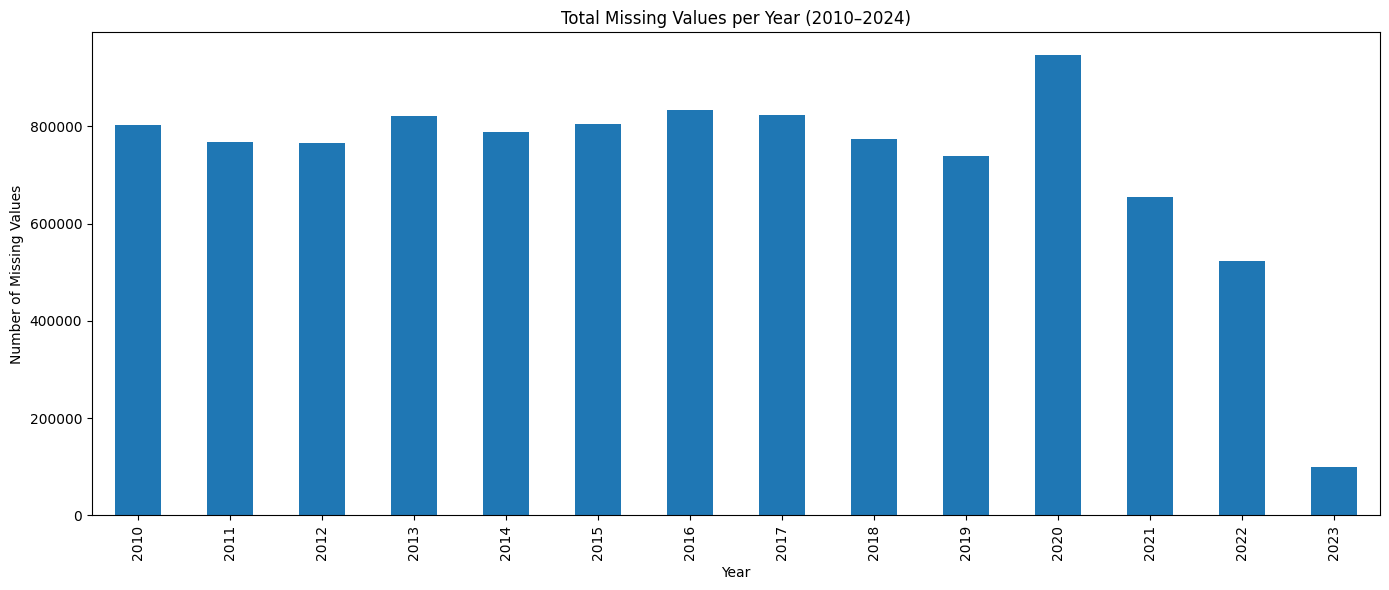

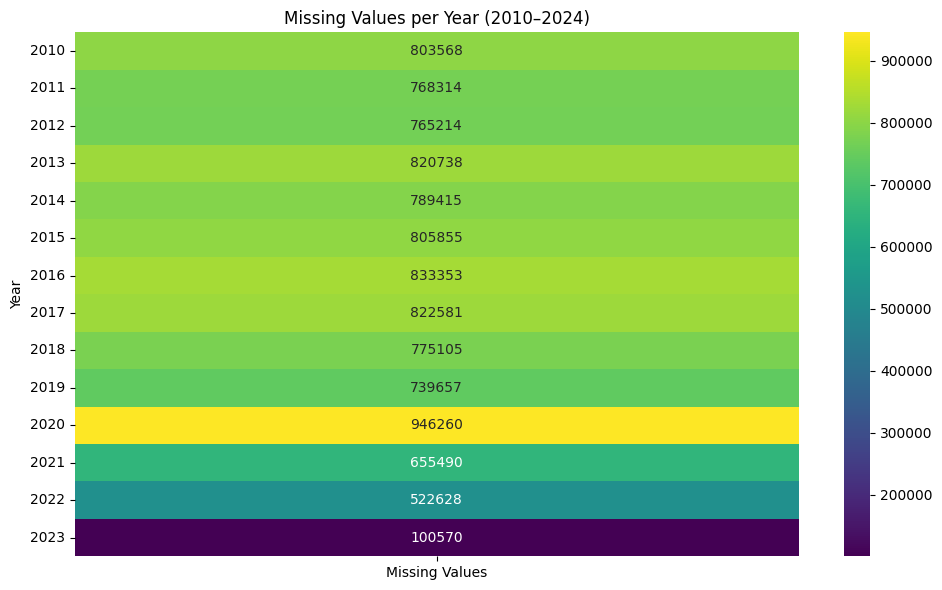

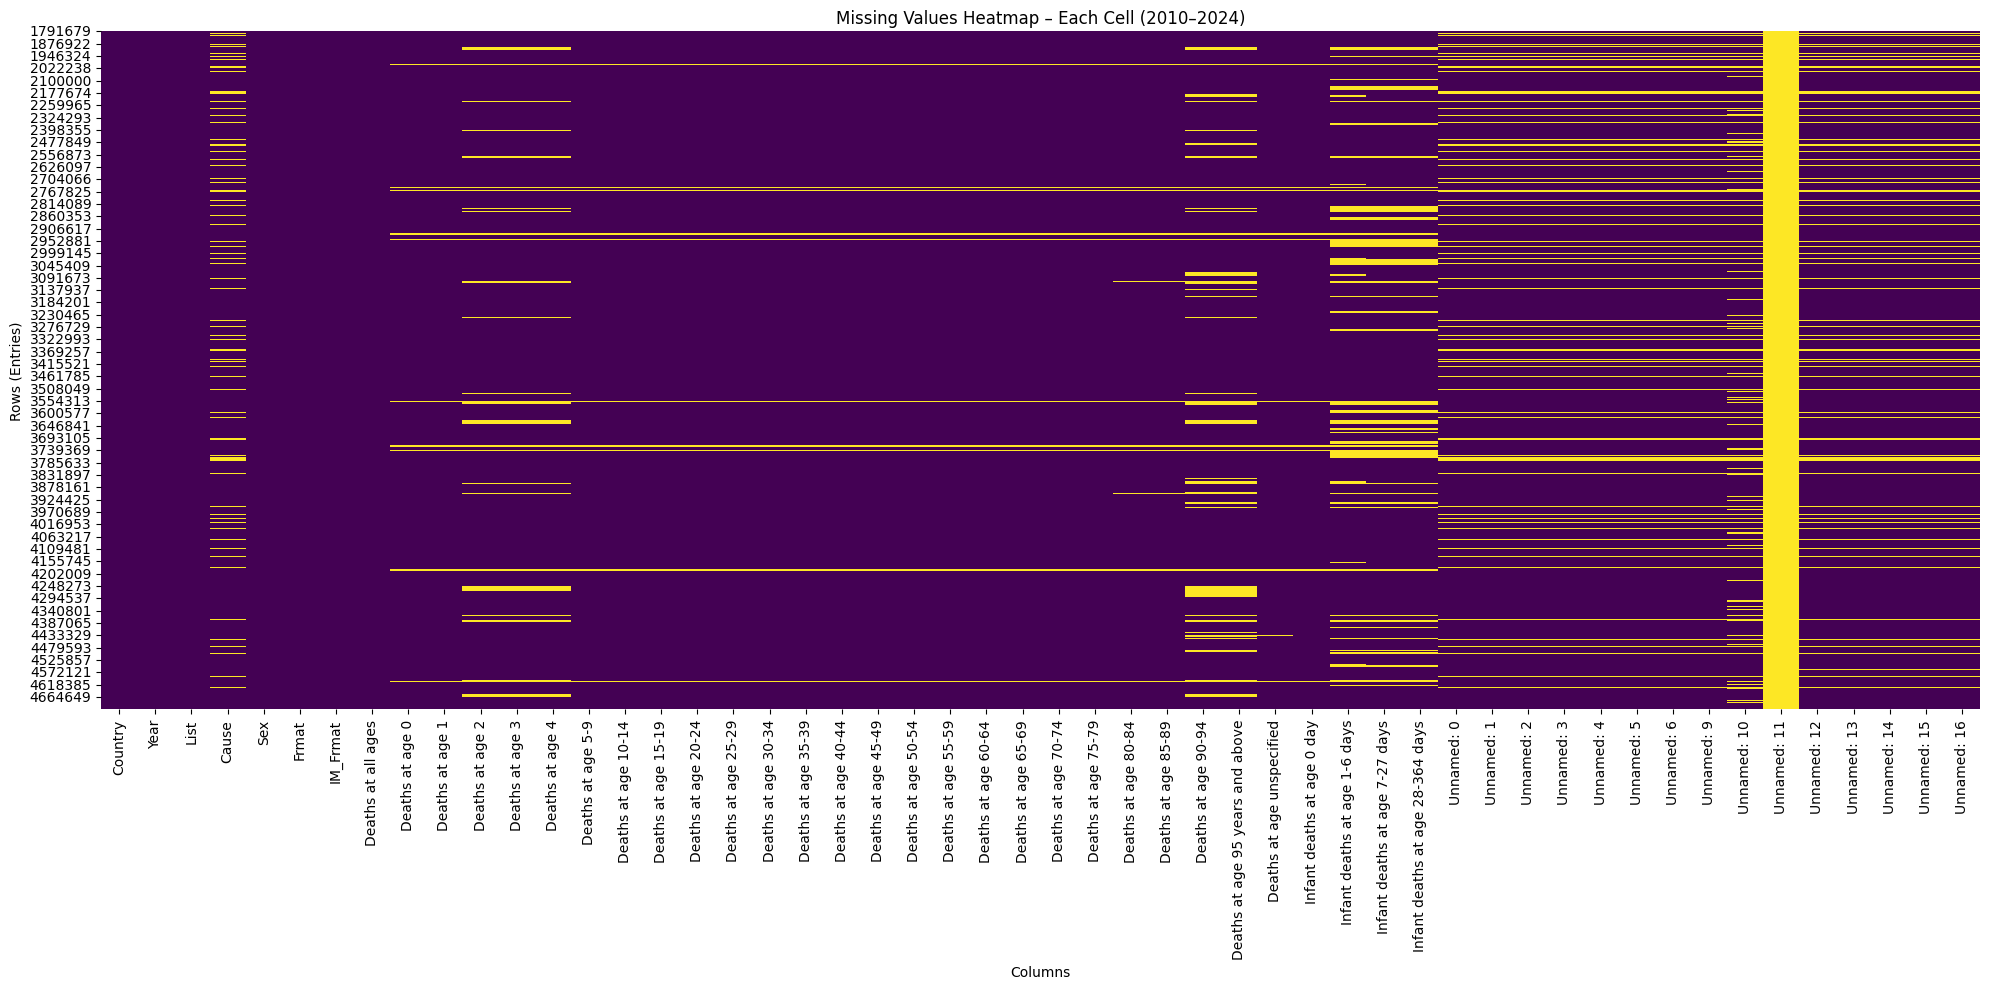

In [8]:
# Missing Values pro Jahr berechnen
missing_by_year = df_period.groupby("Year").apply(lambda x: x.isna().sum().sum())

# In ein DataFrame umwandeln, damit es für eine Heatmap passt
missing_df = missing_by_year.to_frame(name="Missing Values")



plt.figure(figsize=(14, 6))
missing_by_year.plot(kind="bar")
plt.title("Total Missing Values per Year (2010–2024)")
plt.xlabel("Year")
plt.ylabel("Number of Missing Values")
plt.tight_layout()
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(missing_df, annot=True, fmt=".0f", cmap="viridis")
plt.title("Missing Values per Year (2010–2024)")
plt.ylabel("Year")
plt.xlabel("")
plt.tight_layout()
plt.show()

# Heatmap der einzelnen Missing Values
plt.figure(figsize=(20, 10))
sns.heatmap(df_period.isna(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap – Each Cell (2010–2024)")
plt.xlabel("Columns")
plt.ylabel("Rows (Entries)")
plt.tight_layout()
plt.show()



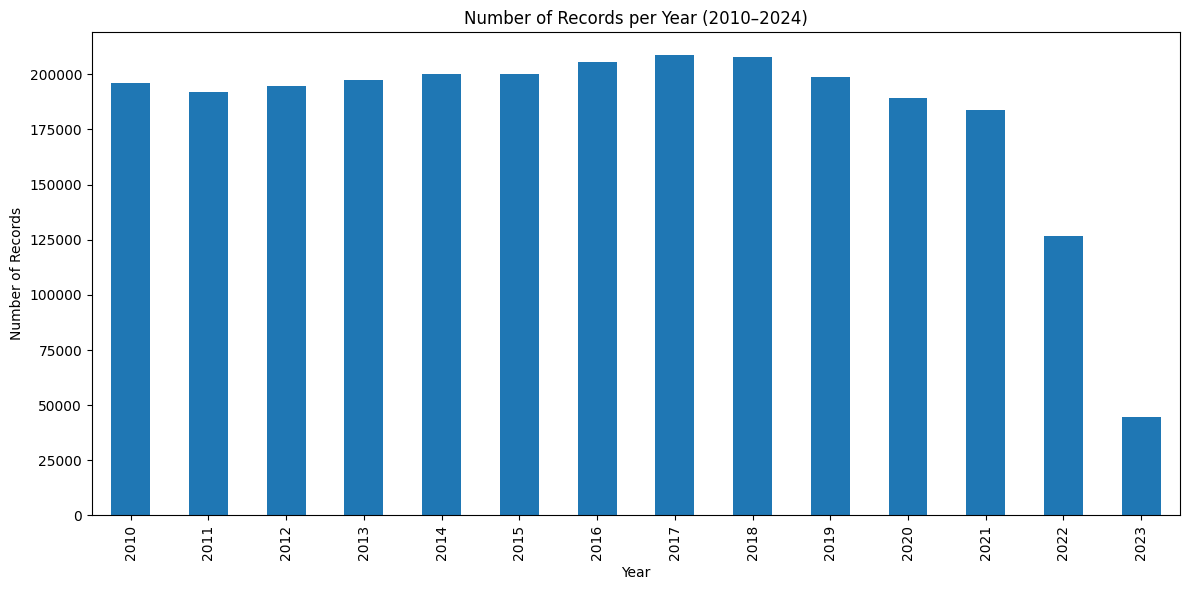

In [9]:
# Anzahl Zeilen pro Jahr berechnen
records_per_year = df_period.groupby("Year").size()

plt.figure(figsize=(12, 6))
records_per_year.plot(kind="bar")
plt.title("Number of Records per Year (2010–2024)")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [10]:
# 3. Nur Zeilen mit gültiger Cause behalten
df_2017 = df_2017[df_2017['Cause'].notna() & (df_2017['Cause'] != '')]

# 4. Doppelte Einträge entfernen
unique_cols = ['Country', 'Sex', 'Cause', 'Year']
df_2017_unique = df_2017.drop_duplicates(subset=unique_cols)
# 3. Summieren
result = (
    df_2017_unique
    .groupby('Country')['Deaths at all ages']
    .sum()
    .sort_values(ascending=False)
)

print(result)

Country
United States of America             2622466
Japan                                1340118
Brazil                               1196046
Germany                               932107
Italy                                 650455
Mexico                                634911
France                                591276
United Kingdom                        587481
United Kingdom, England and Wales     517086
Thailand                              435650
Spain                                 412878
Turkey                                411692
Poland                                388255
Iran (Islamic Republic of)            331815
Argentina                             330603
Republic of Korea                     267563
Canada                                261494
Romania                               255509
Colombia                              206127
Australia                             161075
Netherlands                           150194
Hungary                               126949
Gr

# PART2 EXPLORATIVE STATISTIK

MMM

Streuung

Boxplot

Outlier (Tukey + Modified Z)

We use the data of the data.worldbank.org API to get the population of each country for each year. This allows us to calculate the death per 100,000 people for each country and year.

<>:65: SyntaxWarning: invalid escape sequence '\A'
<>:65: SyntaxWarning: invalid escape sequence '\A'
C:\Users\benma\AppData\Local\Temp\ipykernel_26612\1352873257.py:65: SyntaxWarning: invalid escape sequence '\A'
  pop_raw = pd.read_csv("Data_Files\API_SP.POP.TOTL_DS2_en_csv_v2_280659.csv", skiprows=4)
C:\Users\benma\AppData\Local\Temp\ipykernel_26612\1352873257.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2017_unique["Country_clean"] = df_2017_unique["Country"].replace(country_map)
C:\Users\benma\AppData\Local\Temp\ipykernel_26612\1352873257.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

Fehlende ISO3-Zuordnung: ['Iran (Islamic Republic of)']
   ISO3  Deaths_per_100k
28  GBR      1781.172119
7   BGR      1584.221459
46  LTU      1412.138509
48  LVA      1393.076476
36  HUN      1305.152509

--- Lage & Streuung ---
Mittelwert: 723.79
Median:     665.84
Std-Abw:    358.19
IQR:        473.60

--- Tukey Outliers ---
   ISO3  Deaths_per_100k
28  GBR      1781.172119

--- Modified Z Outliers ---
Empty DataFrame
Columns: [ISO3, Deaths_per_100k]
Index: []

--- Zusammenfassung ---
     Statistic        Value
0         Mean   723.786258
1       Median   665.842613
2      Std Dev   358.186861
3          IQR   473.596102
4  Lower Fence  -265.089388
5  Upper Fence  1629.295020


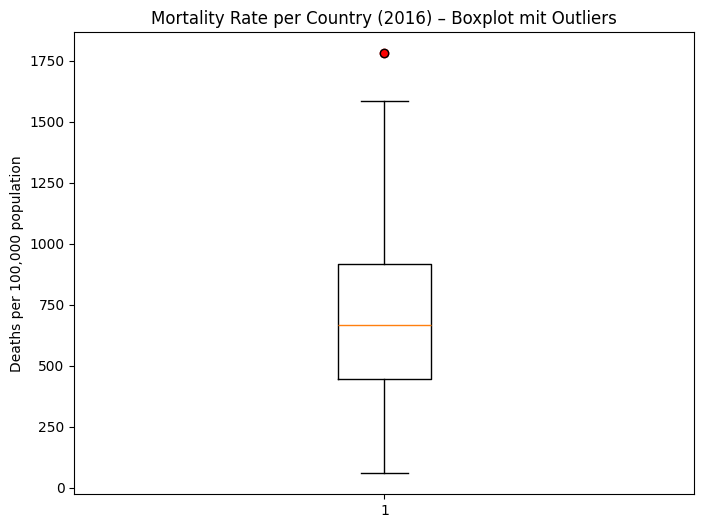

In [20]:
# -----------------------------
# 5. Country-Mapping für Subregionen
# -----------------------------
country_map = {
    "United States of America": "United States",
    "Czech Republic": "Czechia",
    "Republic of Korea": "Korea, Republic of",
    "Republic of Moldova": "Moldova",
    "Turkey": "Türkiye",
    "Venezuela": "Venezuela, Bolivarian Republic of",

    # UK Subs
    "United Kingdom, England and Wales": "United Kingdom",
    "United Kingdom, Scotland": "United Kingdom",
    "United Kingdom, Northern Ireland": "United Kingdom",

    # China / France Subregions
    "Hong Kong SAR": "Hong Kong",
    "Reunion": "France",
    "Guadeloupe": "France",
    "Martinique": "France",
    "Mayotte": "France",
    "French Guiana": "France",
    "Rodrigues": "Mauritius",
    "Puerto Rico": "United States",
    "Virgin Islands (USA)": "United States",

    # Caribbean and small states
    "Saint Vincent and Grenadines": "Saint Vincent and the Grenadines",
    "Saint Lucia": "Saint Lucia",
    "Saint Kitts and Nevis": "Saint Kitts and Nevis",
    "Grenada": "Grenada",
    "Aruba": "Aruba",
    "Maldives": "Maldives",
    "Bermuda": "Bermuda",
    "Belize": "Belize",
    "British Virgin Islands": "British Virgin Islands",
    "Turks and Caicos Islands": "Turks and Caicos Islands",
    "Montserrat": "Montserrat",
    "Antigua and Barbuda": "Antigua and Barbuda",
    "Cayman Islands": "Cayman Islands"
}

df_2017_unique["Country_clean"] = df_2017_unique["Country"].replace(country_map)

# -----------------------------
# 6. ISO3 Codes generieren
# -----------------------------
def name_to_iso3(country_name):
    try:
        result = pycountry.countries.lookup(country_name)
        return result.alpha_3
    except:
        return None

df_2017_unique["ISO3"] = df_2017_unique["Country_clean"].apply(name_to_iso3)

# Optional: ansehen, welche Länder nicht gemappt wurden
missing_iso = df_2017_unique[df_2017_unique["ISO3"].isna()]["Country"].unique()
print("Fehlende ISO3-Zuordnung:", missing_iso)

# -----------------------------
# 7. World Bank Population-Daten einlesen
# -----------------------------
pop_raw = pd.read_csv("Data_Files\API_SP.POP.TOTL_DS2_en_csv_v2_280659.csv", skiprows=4)

pop_2017 = pop_raw[["Country Code", "2017"]].rename(
    columns={"Country Code": "ISO3", "2017": "Population"}
)

# -----------------------------
# 8. Merge WHO + Population
# -----------------------------
df_merged = df_2017_unique.merge(
    pop_2017,
    on="ISO3",
    how="inner"
)

# -----------------------------
# 9. Todesfälle pro 100k berechnen
# -----------------------------
df_merged["Deaths_per_100k"] = (
    df_merged["Deaths at all ages"] / df_merged["Population"] * 100000
)

# -----------------------------
# 10. Für Boxplot aggregieren
# -----------------------------
mortality_per_country = (
    df_merged.groupby("ISO3")["Deaths_per_100k"]
    .sum()
    .reset_index()
)

print(mortality_per_country.sort_values("Deaths_per_100k", ascending=False).head())




import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Werte extrahieren
values = mortality_per_country["Deaths_per_100k"]

# -------------------------
# 1. Lage & Streuung
# -------------------------
mean_val   = values.mean()
median_val = values.median()
std_val    = values.std()
iqr_val    = values.quantile(0.75) - values.quantile(0.25)

print("\n--- Lage & Streuung ---")
print(f"Mittelwert: {mean_val:.2f}")
print(f"Median:     {median_val:.2f}")
print(f"Std-Abw:    {std_val:.2f}")
print(f"IQR:        {iqr_val:.2f}")


# -------------------------
# 2. Outliers nach Tukey Fences
# -------------------------
Q1 = values.quantile(0.25)
Q3 = values.quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

tukey_outliers = mortality_per_country[
    (mortality_per_country["Deaths_per_100k"] < lower_fence) |
    (mortality_per_country["Deaths_per_100k"] > upper_fence)
][["ISO3", "Deaths_per_100k"]]

print("\n--- Tukey Outliers ---")
print(tukey_outliers)


# -------------------------
# 3. Outliers nach Modified Z-Score
# -------------------------
median_val = values.median()
MAD = np.median(np.abs(values - median_val))

mod_z = 0.6745 * (values - median_val) / MAD

modz_outliers = mortality_per_country[np.abs(mod_z) > 3.5][["ISO3", "Deaths_per_100k"]]

print("\n--- Modified Z Outliers ---")
print(modz_outliers)


# -------------------------
# 4. Zusammenfassende Tabelle
# -------------------------
summary_table = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Std Dev", "IQR", "Lower Fence", "Upper Fence"],
    "Value": [mean_val, median_val, std_val, iqr_val, lower_fence, upper_fence]
})

print("\n--- Zusammenfassung ---")
print(summary_table)


# -------------------------
# 5. Boxplot mit Outlier-Markierung (optional, aber schön)
# -------------------------
plt.figure(figsize=(8,6))
plt.boxplot(values, vert=True)

# Outlier-Labels
outliers = tukey_outliers["Deaths_per_100k"].values
for o in outliers:
    plt.scatter(1, o, color="red")

plt.title("Mortality Rate per Country (2016) – Boxplot mit Outliers")
plt.ylabel("Deaths per 100,000 population")
plt.show()





['Deaths at age 0', 'Deaths at age 1', 'Deaths at age 2', 'Deaths at age 3', 'Deaths at age 4', 'Deaths at age 5-9', 'Deaths at age 10-14', 'Deaths at age 15-19', 'Deaths at age 20-24', 'Deaths at age 25-29', 'Deaths at age 30-34', 'Deaths at age 35-39', 'Deaths at age 40-44', 'Deaths at age 45-49', 'Deaths at age 50-54', 'Deaths at age 55-59', 'Deaths at age 60-64', 'Deaths at age 65-69', 'Deaths at age 70-74', 'Deaths at age 75-79', 'Deaths at age 80-84', 'Deaths at age 85-89', 'Deaths at age 90-94', 'Deaths at age 95 years and above', 'Deaths at age unspecified']


C:\Users\benma\AppData\Local\Temp\ipykernel_26612\1817090181.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rate_only.values, labels=age_cols, vert=True)


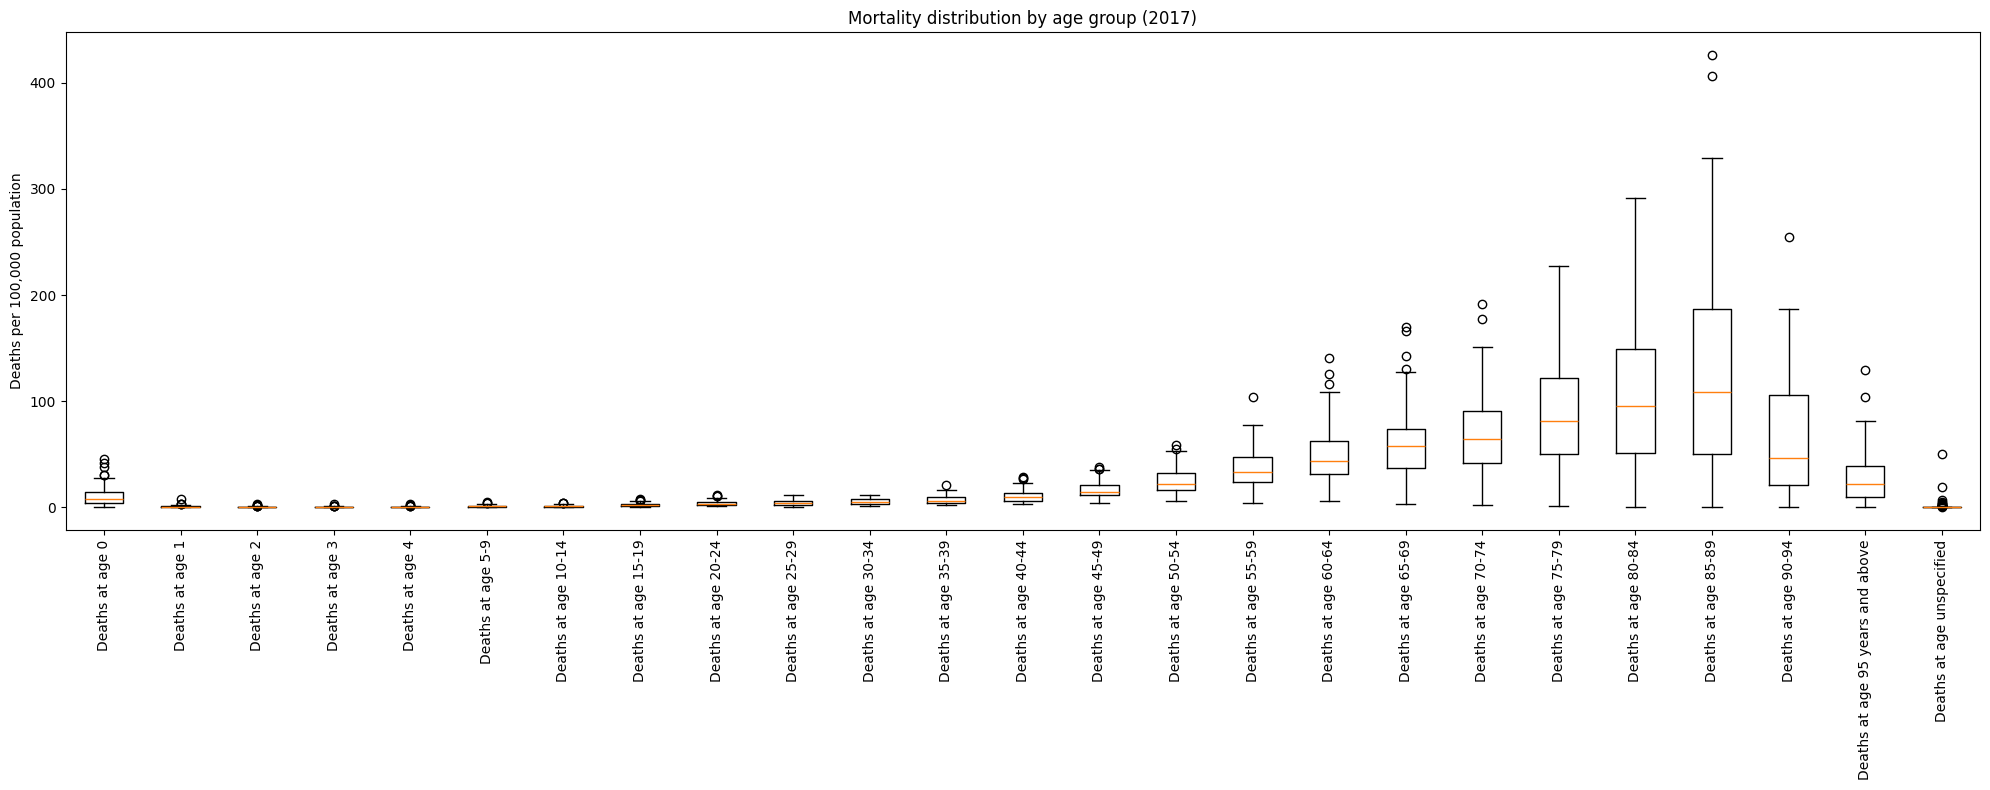

In [12]:
## Boxplot für jede altersgruppe

# finde alle Spalten, die mit "Deaths at age" beginnen
age_cols = [col for col in df_2017_unique.columns if "Deaths at age" in col]

print(age_cols)

# Summe pro Land (alle Causes zusammen)
age_by_country = df_2017_unique.groupby("ISO3")[age_cols].sum().reset_index()

age_by_country = age_by_country.merge(
    pop_2017, on="ISO3", how="inner"
)

for col in age_cols:
    age_by_country[col] = (
        age_by_country[col] / age_by_country["Population"] * 100000
    )

rate_only = age_by_country[age_cols]

plt.figure(figsize=(20, 8))
plt.boxplot(rate_only.values, labels=age_cols, vert=True)

plt.xticks(rotation=90)
plt.ylabel("Deaths per 100,000 population")
plt.title("Mortality distribution by age group (2017)")

plt.tight_layout()
plt.show()




# PART3 VERTEILUNGEN

Histogramm + KDE

ECDF

QQ-Plot (zeigt Nicht-Normalverteilung)

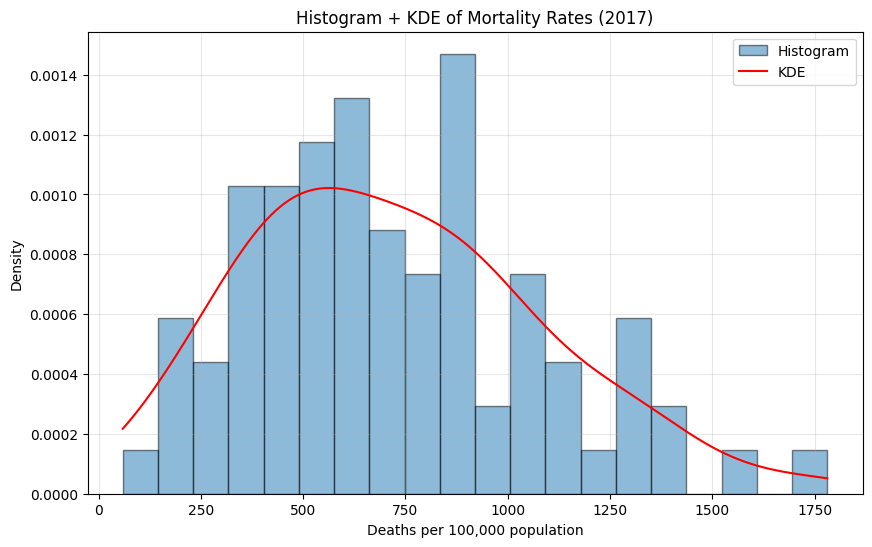

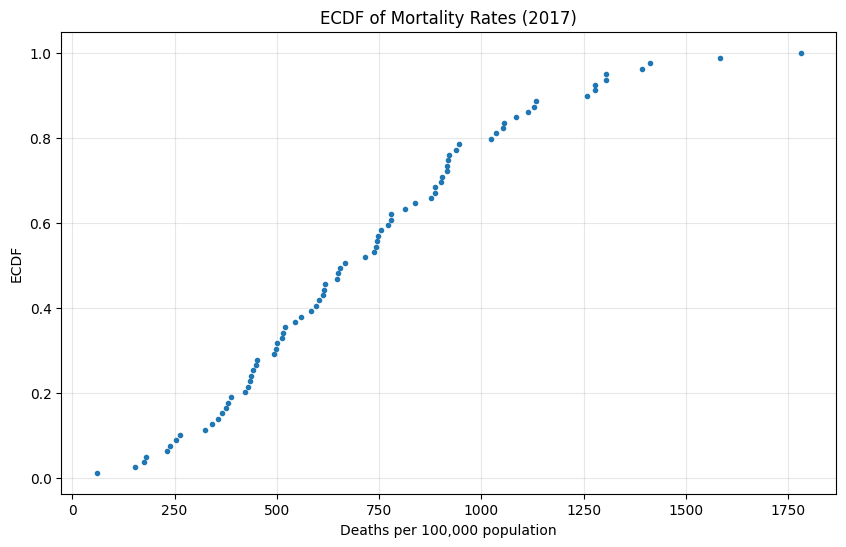

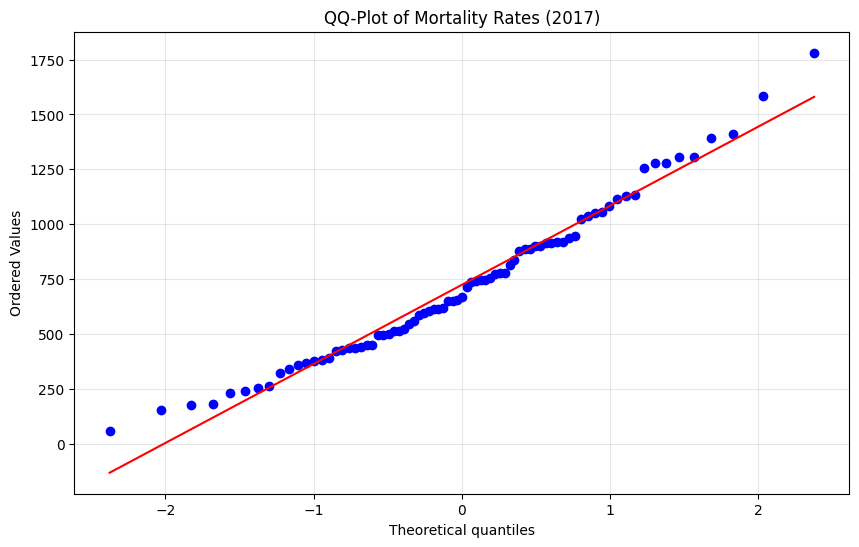

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

values = mortality_per_country["Deaths_per_100k"]

# ------------------------------------------------
# 1. Histogram + KDE
# ------------------------------------------------
plt.figure(figsize=(10, 6))
plt.hist(values, bins=20, density=True, alpha=0.5, edgecolor="black", label="Histogram")

# KDE (Kernel Density Estimation)
density = stats.gaussian_kde(values)
x_vals = np.linspace(values.min(), values.max(), 500)
plt.plot(x_vals, density(x_vals), color="red", label="KDE")

plt.xlabel("Deaths per 100,000 population")
plt.ylabel("Density")
plt.title("Histogram + KDE of Mortality Rates (2017)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# ------------------------------------------------
# 2. ECDF (Empirical Cumulative Distribution Function)
# ------------------------------------------------
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

x_ecdf, y_ecdf = ecdf(values)

plt.figure(figsize=(10, 6))
plt.plot(x_ecdf, y_ecdf, marker='.', linestyle='none')
plt.xlabel("Deaths per 100,000 population")
plt.ylabel("ECDF")
plt.title("ECDF of Mortality Rates (2017)")
plt.grid(alpha=0.3)
plt.show()


# ------------------------------------------------
# 3. QQ-Plot (Check Normality)
# ------------------------------------------------
plt.figure(figsize=(10, 6))
stats.probplot(values, dist="norm", plot=plt)
plt.title("QQ-Plot of Mortality Rates (2017)")
plt.grid(alpha=0.3)
plt.show()


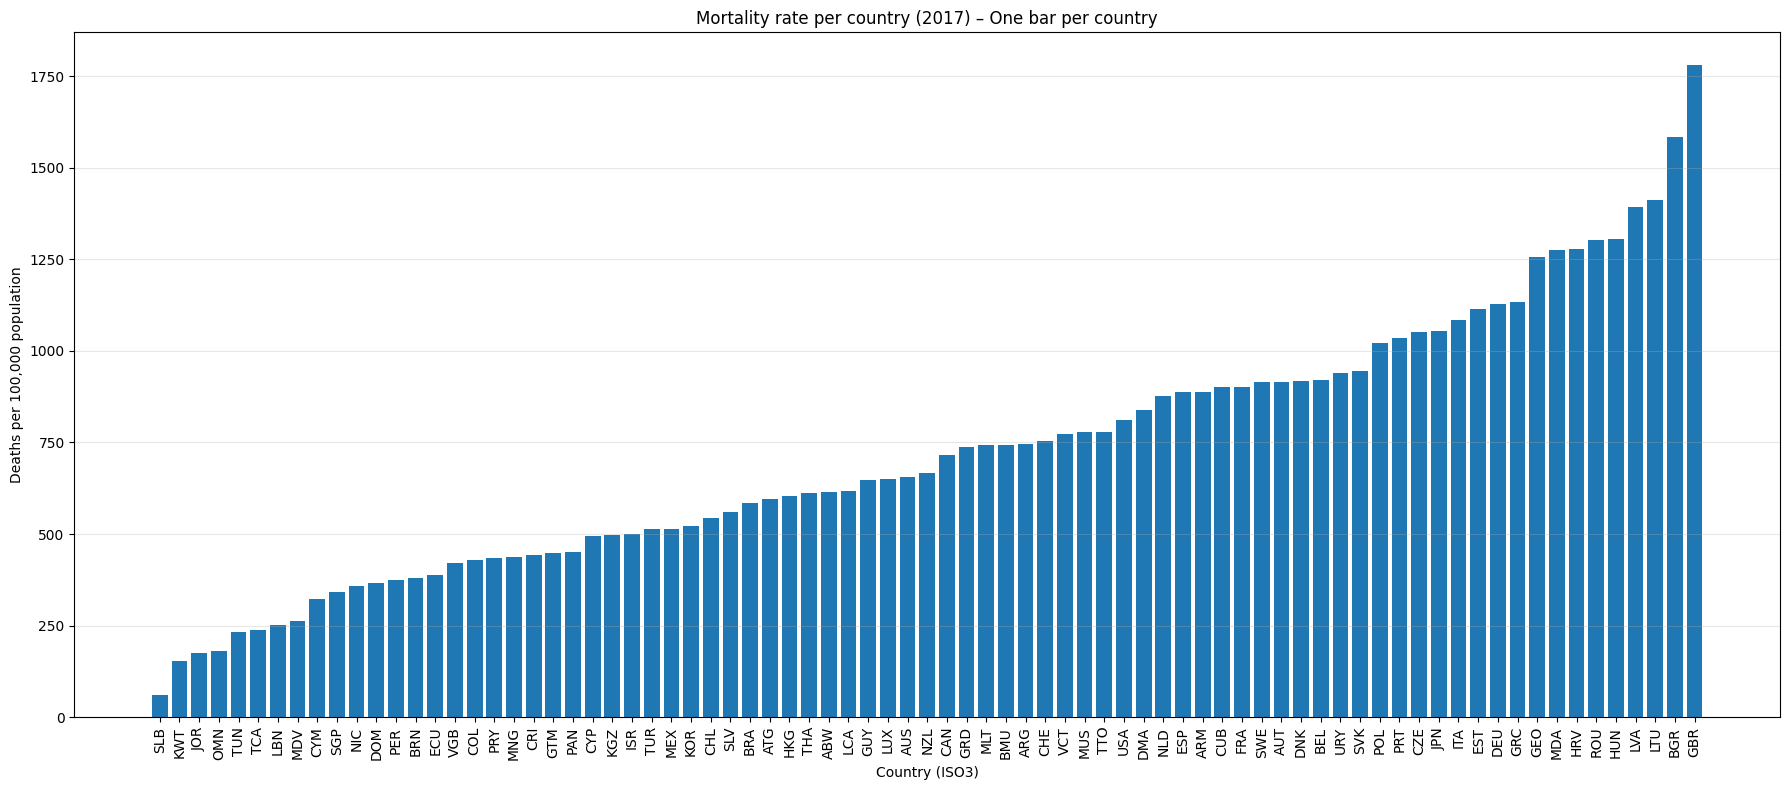

In [14]:
# Sortieren nach Todesrate (optional, sieht schöner aus)
mort_sorted = mortality_per_country.sort_values("Deaths_per_100k")

plt.figure(figsize=(18, 8))
plt.bar(mort_sorted["ISO3"], mort_sorted["Deaths_per_100k"])

plt.xlabel("Country (ISO3)")
plt.ylabel("Deaths per 100,000 population")
plt.title("Mortality rate per country (2017) – One bar per country")

# X-Achse lesbarer machen
plt.xticks(rotation=90)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# ZUSAMMENHÄNGE LIFE EXPECTANCY VS MORTALITY RATE

Pearson, Spearman

Regression

Life Expectancy vs Mortality (kein Zusammenhang)

Median Age vs Mortality (starker Zusammenhang)

Die Schweiz hat eine höhere Mortalitätsrate als Kolumbien,
weil sie eine wesentlich ältere Bevölkerung hat und eine viel höhere Lebenserwartung.
In Ländern mit junger Bevölkerung sterben pro 100’000 Menschen automatisch weniger Leute.

<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
C:\Users\benma\AppData\Local\Temp\ipykernel_26612\3256741462.py:5: SyntaxWarning: invalid escape sequence '\A'
  age_0_14_raw = pd.read_csv("Data_Files\API_SP.POP.0014.TO.ZS_DS2_en_csv_v2_253632.csv", skiprows=4)
C:\Users\benma\AppData\Local\Temp\ipykernel_26612\3256741462.py:7: SyntaxWarning: invalid escape sequence '\A'
  age_65_raw = pd.read_csv("Data_Files\API_SP.POP.65UP.TO.ZS_DS2_en_csv_v2_8582.csv", skiprows=4)


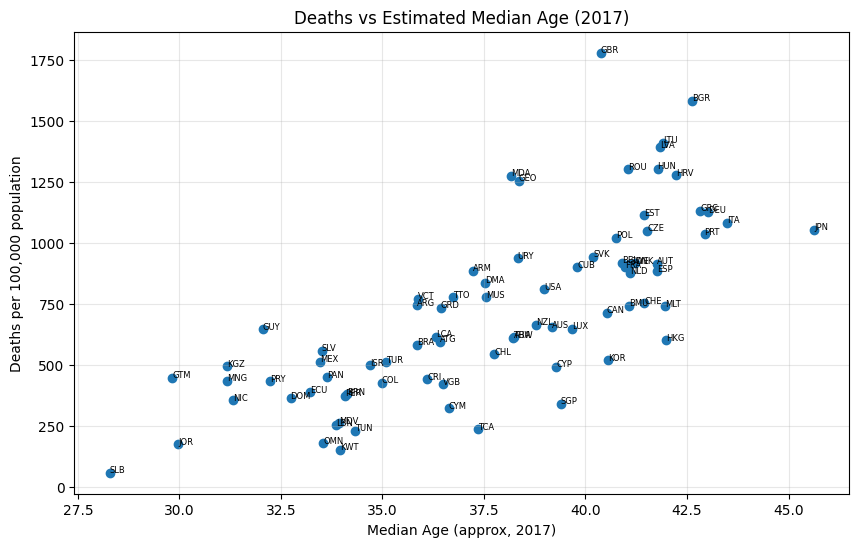

In [15]:
## Deats per 100k vs median age scatter plot
# -----------------------------     

#Daten Einlesen
age_0_14_raw = pd.read_csv("Data_Files\API_SP.POP.0014.TO.ZS_DS2_en_csv_v2_253632.csv", skiprows=4)
age_15_64_raw = pd.read_csv("Data_Files/API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_294218.csv", skiprows=4)
age_65_raw = pd.read_csv("Data_Files\API_SP.POP.65UP.TO.ZS_DS2_en_csv_v2_8582.csv", skiprows=4)


# 2016 Daten extrahieren
age_0_14 = age_0_14_raw[["Country Code", "2017"]].rename(
    columns={"Country Code": "ISO3", "2017": "pct_0_14"}
)

age_15_64 = age_15_64_raw[["Country Code", "2017"]].rename(
    columns={"Country Code": "ISO3", "2017": "pct_15_64"}
)

age_65 = age_65_raw[["Country Code", "2017"]].rename(
    columns={"Country Code": "ISO3", "2017": "pct_65plus"}
)

# Merge Altersdaten
age_all = age_0_14.merge(age_15_64, on="ISO3", how="inner") \
                  .merge(age_65, on="ISO3", how="inner")

#Median Age berechnen
age_all["median_age_proxy"] = (
    7 * (age_all["pct_0_14"] / 100) +
    40 * (age_all["pct_15_64"] / 100) +
    75 * (age_all["pct_65plus"] / 100)
)

# Merge mit Mortalitätsdaten
scatter_data = mortality_per_country.merge(age_all, on="ISO3", how="inner")

# Scatter Plot erstellen
plt.figure(figsize=(10,6))

plt.scatter(scatter_data["median_age_proxy"], scatter_data["Deaths_per_100k"])

plt.xlabel("Median Age (approx, 2017)")
plt.ylabel("Deaths per 100,000 population")
plt.title("Deaths vs Estimated Median Age (2017)")

plt.grid(alpha=0.3)

# Option: Länderlabels anzeigen
for i, row in scatter_data.iterrows():
    plt.text(row["median_age_proxy"], row["Deaths_per_100k"], row["ISO3"], fontsize=6)

plt.show()




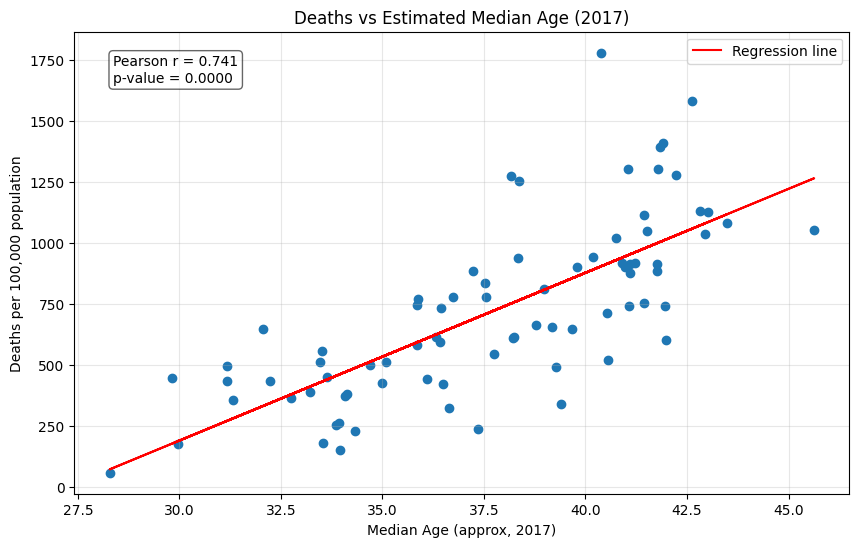

In [16]:
### Korrelationskoeffizient berechnen
import numpy as np
from scipy.stats import pearsonr

# ---------------------------
# Daten aus Median-Age-Proxy-Plot holen
# ---------------------------
x = scatter_data["median_age_proxy"].values
y = scatter_data["Deaths_per_100k"].values

# ---------------------------
# Lineare Regression
# ---------------------------
slope, intercept = np.polyfit(x, y, 1)
reg_line = slope * x + intercept

# ---------------------------
# Pearson-Korrelation
# ---------------------------
corr, p_value = pearsonr(x, y)

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(10, 6))

# Scatterplot
plt.scatter(x, y)

# Regressionslinie
plt.plot(x, reg_line, color="red", label="Regression line")

# Labels
plt.xlabel("Median Age (approx, 2017)")
plt.ylabel("Deaths per 100,000 population")
plt.title("Deaths vs Estimated Median Age (2017)")

# Korrelationsinfo ins Plot schreiben
plt.text(
    0.05, 0.95,
    f"Pearson r = {corr:.3f}\np-value = {p_value:.4f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.6)
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()


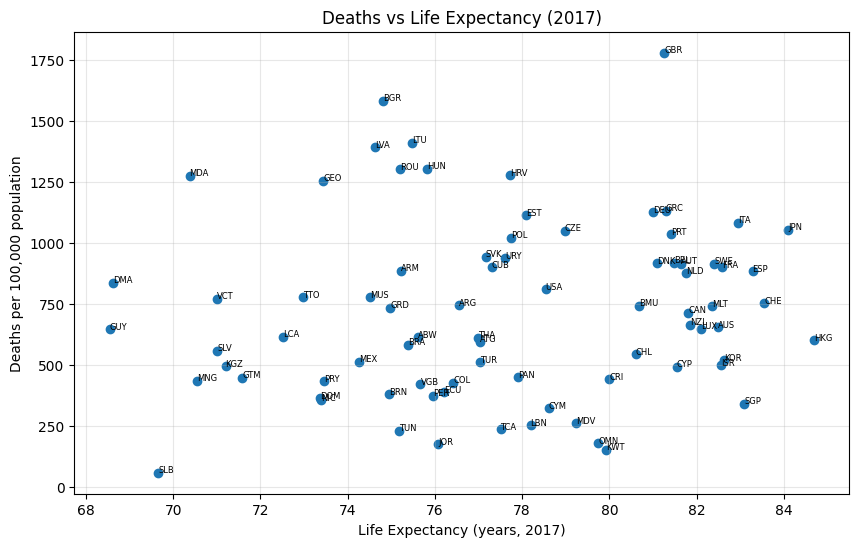

In [17]:
### Life expectancy vs Deaths per 100k scatter plot
# -----------------------------

# ---------------------------------------
# 1. Lebenserwartungs-Datei einlesen
# ---------------------------------------
life_raw = pd.read_csv(
    "Data_Files/API_SP.DYN.LE00.IN_DS2_en_csv_v2_309535.csv",
    skiprows=4
)

# ---------------------------------------
# 2. Nur ISO3 + Jahr 2017 extrahieren
# ---------------------------------------
life_2017 = life_raw[["Country Code", "2017"]].rename(
    columns={"Country Code": "ISO3", "2017": "LifeExpectancy"}
)

# ---------------------------------------
# 3. Merge mit deinen Mortalitätsdaten
# ---------------------------------------
scatter_life = mortality_per_country.merge(life_2017, on="ISO3", how="inner")

# Falls NaN-Werte drin sind -> rauswerfen
scatter_life = scatter_life.dropna(subset=["LifeExpectancy"])

# ---------------------------------------
# 4. Scatterplot
# ---------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(scatter_life["LifeExpectancy"], scatter_life["Deaths_per_100k"])

plt.xlabel("Life Expectancy (years, 2017)")
plt.ylabel("Deaths per 100,000 population")
plt.title("Deaths vs Life Expectancy (2017)")

plt.grid(alpha=0.3)

# ---------------------------------------
# 5. Länderlabels anzeigen (optional)
# ---------------------------------------
for i, row in scatter_life.iterrows():
    plt.text(
        row["LifeExpectancy"],
        row["Deaths_per_100k"],
        row["ISO3"],
        fontsize=6
    )

plt.show()


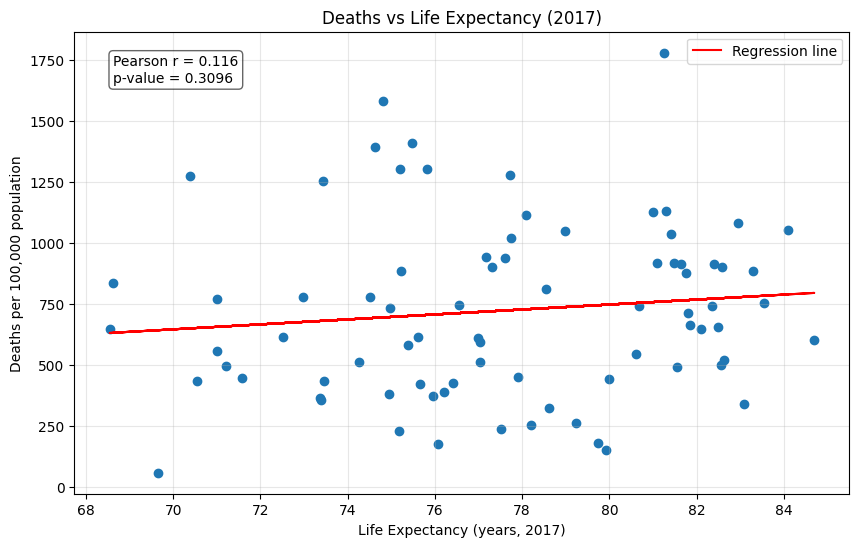

In [18]:
### Berechnen des Korrelationskoeffizienten

from scipy.stats import pearsonr
# ---------------------------
# Daten holen
# ---------------------------
x = scatter_life["LifeExpectancy"].values
y = scatter_life["Deaths_per_100k"].values

# ---------------------------
# Lineare Regression
# ---------------------------
slope, intercept = np.polyfit(x, y, 1)
reg_line = slope * x + intercept

# ---------------------------
# Pearson-Korrelation
# ---------------------------
corr, p_value = pearsonr(x, y)

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(10, 6))

# Scatterplot
plt.scatter(x, y)

# Regressionslinie
plt.plot(x, reg_line, color="red", label=f"Regression line")

# Labels
plt.xlabel("Life Expectancy (years, 2017)")
plt.ylabel("Deaths per 100,000 population")
plt.title("Deaths vs Life Expectancy (2017)")

# Korrelationsinfo ins Plot schreiben
plt.text(
    0.05, 0.95,
    f"Pearson r = {corr:.3f}\np-value = {p_value:.4f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.6)
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()

🔵 Länder mit hoher LE, aber tiefen Sterberaten
→ junge, gesunde Bevölkerungen
→ SGP, CHL, AUS, CAN etc.

🔵 Länder mit hoher LE, aber hohen Sterberaten
→ sehr alte Bevölkerungen
→ ITA, ESP, JPN, CHE, PRT etc.

🔵 Länder mit niedriger LE, aber tiefen Sterberaten
→ junge, aber ärmere Länder
→ MAR, MNG, PER, GTM, IND

🔵 Länder mit niedriger LE, aber hohen Sterberaten
→ selten, aber möglich
→ GEO, BGR, LVA